In [1]:
# =========================================================
# 사출성형기 AI 데이터셋 EDA
# 파일: supervised_label_cn7.csv
# =========================================================

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ---------------------------------------------------------
# 1. 라이브러리 불러오기
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ---------------------------------------------------------
# 2. 기본 설정
# ---------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [5]:
# ---------------------------------------------------------
# 1. 한글/그래프 기본 설정
# ---------------------------------------------------------
import platform
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:                           # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

In [6]:
# ---------------------------------------------------------
# 3. 데이터 불러오기
# ---------------------------------------------------------
file_path = "supervised_label_cn7.csv"
df = pd.read_csv(file_path, index_col=0) # 첫번째 컬럼이 인덱스

target_col = "PassOrFail"

print("=== 원본 데이터 ===")
display(df)

=== 원본 데이터 ===


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.60,4.48,16.910000,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.600000
1,0,9.59,4.48,16.910000,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.600000
2,0,9.58,4.46,16.900000,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.600000
3,0,9.58,4.46,16.920000,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.600000
4,0,9.57,4.45,16.910000,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6731,0,9.58,4.46,16.670000,59.520000,7.11,653.429993,68.339996,647.98999,55.200001,30.600000,29.200001,142.199997,136.399994,37.900002,59.700001,275.799988,275.500000,275.500000,269.500000,255.000000,230.199997,66.000000,21.000000,22.400000
6732,0,9.60,4.49,16.650000,59.540001,7.11,653.429993,68.320000,647.98999,54.900002,30.799999,29.200001,142.100006,136.899994,38.099998,59.799999,276.100006,275.899994,274.899994,269.700012,254.600006,229.600006,65.400002,21.000000,22.400000
6733,0,9.60,4.48,16.620001,59.560001,7.11,653.429993,68.330002,647.98999,54.900002,30.700001,29.200001,142.100006,137.000000,38.299999,59.900002,276.500000,274.899994,275.100006,269.500000,255.600006,229.600006,66.099998,21.000000,22.400000
6734,0,9.60,4.48,16.650000,59.560001,7.11,653.429993,68.349998,647.98999,55.000000,30.700001,29.200001,142.100006,136.800003,38.400002,59.900002,275.799988,275.299988,275.500000,270.700012,254.899994,230.000000,66.099998,21.000000,22.400000


In [7]:
# ---------------------------------------------------------
# 4. 데이터 기본 구조 확인
# ---------------------------------------------------------
print("=== 데이터 크기 ===")
print(df.shape)

=== 데이터 크기 ===
(6736, 25)


In [8]:
print("=== 컬럼 목록 ===")
print(df.columns.tolist())

=== 컬럼 목록 ===
['PassOrFail', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


In [9]:
print("=== 데이터 정보 ===")
df.info()

=== 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 6736 entries, 0 to 6735
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                6736 non-null   int64  
 1   Injection_Time            6736 non-null   float64
 2   Filling_Time              6736 non-null   float64
 3   Plasticizing_Time         6736 non-null   float64
 4   Cycle_Time                6736 non-null   float64
 5   Clamp_Close_Time          6736 non-null   float64
 6   Cushion_Position          6736 non-null   float64
 7   Plasticizing_Position     6736 non-null   float64
 8   Clamp_Open_Position       6736 non-null   float64
 9   Max_Injection_Speed       6736 non-null   float64
 10  Max_Screw_RPM             6736 non-null   float64
 11  Average_Screw_RPM         6736 non-null   float64
 12  Max_Injection_Pressure    6736 non-null   float64
 13  Max_Switch_Over_Pressure  6736 non-null   float64
 14  Max_

# 데이터 속성정의 표

| Attributes name | Description | Unit |
|---|---|---|
| id | 제조 공정 ID | - |
| TimeStamp | 시간 (YY:HH:MM:SS) | - |
| PART_FACT_PLAN_DATE | 생산을 지시한 날짜 | - |
| PART_FACT_SERIAL | 생산을 지시한 품목에 대한 코드 부여 | - |
| PART_NO* | 제품의 모델 코드 | - |
| PART_NAME | 제품의 이름 | - |
| EQUIP_CD | 생산한 사출기 호기 | - |
| EQUIP_NAME | 생산한 사출기 모델명 | - |
| PassOrFail** | 사출되는 각 물품마다 검수자가 양품 선별을 하여 붙이는 레이블 값 | 0: 불, 1: 합 |
| Reason** | 검수자가 양품 선별 시, 불량으로 확인된 제품에 대해 불량 유형을 나타냄<br>Unlabeled에서는 확인 불가 | - |
| ERR_FACT_QTY | 생산 시 발생한 불량의 개수 | 수량 (개) |
| Injection_Time | 고압 + 사출시간<br>고압(사출압): 재료를 금형에 유입시킬 때의 압력<br>사출시간: 재료를 금형에 유입시키는 데 소요되는 시간 | Sec (초) |
| Filling_Time | 충진시간으로, 사출기에서 금형으로 내용물이 주입되는 시간 | Sec (초) |
| Plasticizing_Time | 계량시간으로, 재료가 스크류에 1번 생산할 만큼 용융되어 저장되는 시간 | Sec (초) |
| Cycle_Time | 1번의 제품 생산에 소요되는 생산시간 | Sec (초) |
| Clamp_Close_Time | 제품이 생산된 후 열려 있는 금형을 사출기가 닫고, 빈틈 없이 고정축과 이동축을 꽉 잡아주는 데 걸리는 시간 | Sec (초) |
| Cushion_Position | 보압(사출압 다음으로 가해지는 압력, 금형 내부 압력을 조절하여 과충전을 방지)을 하기 위한 스크류의 위치 | mm |
| Switch_Over_Position | 고압·보압 절환 위치(고압(사출압)에서 보압으로 전환될 때의 위치) | mm |
| Plasticizing_Position | 계량 완료 위치(계량을 마친 스크류의 위치) | mm |
| Clamp_Open_Position | 제품이 생산되어 추출하기 위해 금형이 열리고 난 위치 | mm |
| Max_Injection_Speed | 배럴에 계량되어 있는 용융수지가 금형으로 흘러들어갈 때 측정되는 최대 속도 | mm/s |
| Max_Screw_RPM | 사출을 위한 스크류의 최대 속도 | mm/s |
| Average_Screw_RPM | 사출을 위한 스크류의 평균 속도 | mm/s |
| Max_Injection_Pressure | 배럴에 계량되어 있는 용융수지가 금형으로 흘러들어갈 때 가해지는 최대 압력 | MPa |
| Max_Switch_Over_Pressure | 사출에서 보압(충진된 수지가 밀리지 않게 압력을 줌)으로 변환되는 압력 | MPa |
| Max_Back_Pressure | 수지가 계량되는 중 스크류가 밀려나는 현상을 저지하기 위한 최대 압력 | MPa |
| Average_Back_Pressure | 수지가 계량되는 중 스크류가 밀려나는 현상을 저지하기 위한 평균 압력 | MPa |
| Barrel_Temperature_1 | 계량 및 사출 시 수지가 일정하게 용융(녹임) 상태를 유지하기 위해 필요한 온도 | 섭씨 (°C) |
| Barrel_Temperature_2 | 배럴 온도 2 | 섭씨 (°C) |
| Barrel_Temperature_3 | 배럴 온도 3 | 섭씨 (°C) |
| Barrel_Temperature_4 | 배럴 온도 4 | 섭씨 (°C) |
| Barrel_Temperature_5 | 배럴 온도 5 | 섭씨 (°C) |
| Barrel_Temperature_6 | 배럴 온도 6 | 섭씨 (°C) |
| Barrel_Temperature_7 | 배럴 온도 7 | 섭씨 (°C) |
| Hopper_Temperature | 재료 주입구의 온도(충분히 건조시키고 재료가 용융되는 시간을 절약하기 위해 온도가 높아야 함) | 섭씨 (°C) |
| Mold_Temperature_1 | 금형 온도 1 | 섭씨 (°C) |
| Mold_Temperature_2 | 금형 온도 2 | 섭씨 (°C) |
| Mold_Temperature_3 | 금형 온도 3 | 섭씨 (°C) |
| Mold_Temperature_4 | 금형 온도 4 | 섭씨 (°C) |
| Mold_Temperature_5 | 금형 온도 5 | 섭씨 (°C) |
| Mold_Temperature_6 | 금형 온도 6 | 섭씨 (°C) |
| Mold_Temperature_7 | 금형 온도 7 | 섭씨 (°C) |
| Mold_Temperature_8 | 금형 온도 8 | 섭씨 (°C) |
| Mold_Temperature_9 | 금형 온도 9 | 섭씨 (°C) |
| Mold_Temperature_10 | 금형 온도 10 | 섭씨 (°C) |
| Mold_Temperature_11 | 금형 온도 11 | 섭씨 (°C) |
| Mold_Temperature_12 | 금형 온도 12 | 섭씨 (°C) |

# 데이터 속성정의 표

## 1. 식별 / 생산 정보

| 컬럼명 | 설명 | 단위 |
|---|---|---|
| id | 제조 공정 ID | - |
| TimeStamp | 시간 (YY:HH:MM:SS) | - |
| PART_FACT_PLAN_DATE | 생산 지시 날짜 | - |
| PART_FACT_SERIAL | 생산 지시 품목 코드 | - |
| PART_NO* | 제품 모델 코드 | - |
| PART_NAME | 제품명 | - |
| EQUIP_CD | 생산한 사출기 호기 | - |
| EQUIP_NAME | 생산한 사출기 모델명 | - |

## 2. 품질 / 라벨 정보

| 컬럼명 | 설명 | 단위 |
|---|---|---|
| PassOrFail** | 검수자가 각 물품에 부여한 레이블 값 (0: 불, 1: 합) | - |
| Reason** | 불량으로 확인된 제품의 불량 유형. Unlabeled에서는 확인 불가 | - |
| ERR_FACT_QTY | 생산 시 발생한 불량 개수 | 수량(개) |

## 3. 시간 관련 공정 변수

| 컬럼명 | 설명 | 단위 |
|---|---|---|
| Injection_Time | 고압+사출시간. 고압(사출압)은 재료를 금형에 유입시킬 때의 압력, 사출시간은 재료를 금형에 유입시키는 데 소요되는 시간 | Sec (초) |
| Filling_Time | 충진시간. 사출기에서 금형으로 내용물이 주입되는 시간 | Sec (초) |
| Plasticizing_Time | 계량시간. 재료가 스크류에 1회 생산분만큼 용융되어 저장되는 시간 | Sec (초) |
| Cycle_Time | 제품 1회 생산에 소요되는 시간 | Sec (초) |
| Clamp_Close_Time | 생산 후 열려 있는 금형을 닫고 고정축과 이동축을 밀착 고정하는 데 걸리는 시간 | Sec (초) |

## 4. 위치 관련 공정 변수

| 컬럼명 | 설명 | 단위 |
|---|---|---|
| Cushion_Position | 보압을 위한 스크류 위치 | mm |
| Switch_Over_Position | 고압에서 보압으로 전환될 때의 위치 | mm |
| Plasticizing_Position | 계량 완료 시 스크류 위치 | mm |
| Clamp_Open_Position | 제품 추출을 위해 금형이 열린 위치 | mm |

## 5. 속도 / 압력 관련 공정 변수

| 컬럼명 | 설명 | 단위 |
|---|---|---|
| Max_Injection_Speed | 용융수지가 금형으로 흘러들어갈 때의 최대 속도 | mm/s |
| Max_Screw_RPM | 스크류의 최대 속도 | mm/s |
| Average_Screw_RPM | 스크류의 평균 속도 | mm/s |
| Max_Injection_Pressure | 용융수지가 금형으로 흘러들어갈 때의 최대 압력 | MPa |
| Max_Switch_Over_Pressure | 사출에서 보압으로 전환될 때의 압력 | MPa |
| Max_Back_Pressure | 계량 중 스크류가 밀려나는 현상을 저지하기 위한 최대 압력 | MPa |
| Average_Back_Pressure | 계량 중 스크류가 밀려나는 현상을 저지하기 위한 평균 압력 | MPa |

## 6. 온도 관련 공정 변수

| 컬럼명 | 설명 | 단위 |
|---|---|---|
| Barrel_Temperature_1 | 계량 및 사출 시 수지가 일정하게 용융 상태를 유지하기 위한 배럴 온도 | 섭씨 (°C) |
| Barrel_Temperature_2 | 배럴 온도 2 | 섭씨 (°C) |
| Barrel_Temperature_3 | 배럴 온도 3 | 섭씨 (°C) |
| Barrel_Temperature_4 | 배럴 온도 4 | 섭씨 (°C) |
| Barrel_Temperature_5 | 배럴 온도 5 | 섭씨 (°C) |
| Barrel_Temperature_6 | 배럴 온도 6 | 섭씨 (°C) |
| Barrel_Temperature_7 | 배럴 온도 7 | 섭씨 (°C) |
| Hopper_Temperature | 재료 주입구의 온도. 충분한 건조와 용융 시간 절약을 위해 높은 온도가 필요 | 섭씨 (°C) |
| Mold_Temperature_1 | 금형 온도 1 | 섭씨 (°C) |
| Mold_Temperature_2 | 금형 온도 2 | 섭씨 (°C) |
| Mold_Temperature_3 | 금형 온도 3 | 섭씨 (°C) |
| Mold_Temperature_4 | 금형 온도 4 | 섭씨 (°C) |
| Mold_Temperature_5 | 금형 온도 5 | 섭씨 (°C) |
| Mold_Temperature_6 | 금형 온도 6 | 섭씨 (°C) |
| Mold_Temperature_7 | 금형 온도 7 | 섭씨 (°C) |
| Mold_Temperature_8 | 금형 온도 8 | 섭씨 (°C) |
| Mold_Temperature_9 | 금형 온도 9 | 섭씨 (°C) |
| Mold_Temperature_10 | 금형 온도 10 | 섭씨 (°C) |
| Mold_Temperature_11 | 금형 온도 11 | 섭씨 (°C) |
| Mold_Temperature_12 | 금형 온도 12 | 섭씨 (°C) |

In [10]:
print("기술통계")
display(df.describe().T)

기술통계


,count,mean,std,min,25%,50%,75%,max
PassOrFail,6736.0,0.005790,0.075876,0.000000,0.000000,0.000000,0.000000,1.000000
Injection_Time,6736.0,9.580064,0.180526,9.360000,9.530000,9.570000,9.600000,13.390000
Filling_Time,6736.0,4.448425,0.140286,3.350000,4.420000,4.450000,4.480000,8.270000
Plasticizing_Time,6736.0,16.820433,0.288946,16.469999,16.629999,16.820000,16.910000,21.100000
Cycle_Time,6736.0,59.549314,0.372267,58.840000,59.480000,59.520000,59.540001,64.349998
Clamp_Close_Time,6736.0,7.113639,0.075843,6.070000,7.120000,7.120000,7.120000,7.180000
Cushion_Position,6736.0,653.440859,0.115004,653.390015,653.429993,653.429993,653.440002,655.000000
Plasticizing_Position,6736.0,68.381941,0.648307,59.759998,68.320000,68.360001,68.510002,68.860001
Clamp_Open_Position,6736.0,644.899046,42.170577,69.639999,647.989990,647.989990,647.989990,647.989990
Max_Injection_Speed,6736.0,55.523085,1.005340,38.500000,55.099998,55.400002,55.900002,64.800003


In [11]:
# ---------------------------------------------------------
# 5. 결측치 / 중복 확인
# ---------------------------------------------------------
print("=== 결측치 개수 ===")
missing_df = df.isnull().sum().to_frame("missing_count")
display(missing_df[missing_df["missing_count"] > 0])

=== 결측치 개수 ===


,missing_count


In [12]:
print("=== 전체 결측치 합계 ===")
print(df.isnull().sum().sum())

=== 전체 결측치 합계 ===
0


In [13]:
print("=== 중복 행 개수 ===")
print(df.duplicated().sum())

=== 중복 행 개수 ===
4729


In [14]:
# ---------------------------------------------------------
# 6. target(PassOrFail) 분포 확인
# ---------------------------------------------------------
print("=== PassOrFail 분포 ===")
target_counts = df["PassOrFail"].value_counts().sort_index()
target_ratio = df["PassOrFail"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "ratio_percent": target_ratio.round(3)
})
display(target_summary)

=== PassOrFail 분포 ===


,count,ratio_percent
PassOrFail,,
0,6697,99.421
1,39,0.579


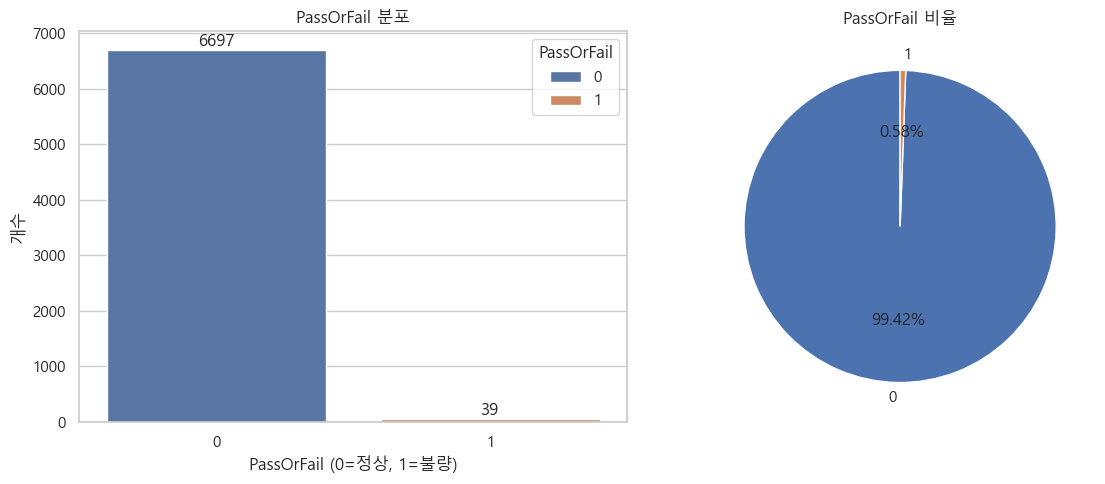

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x='PassOrFail', hue='PassOrFail', dodge=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("PassOrFail 분포")
plt.xlabel("PassOrFail (0=정상, 1=불량)")
plt.ylabel("개수")

plt.subplot(1, 2, 2)
df['PassOrFail'].value_counts().sort_index().plot.pie(
    autopct="%.2f%%",
    startangle=90,
    labels=["0", "1"]
)
plt.title("PassOrFail 비율")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------------
# 7. 수치형 컬럼 목록 정리
# ---------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# target 제외한 입력 변수 컬럼
feature_cols = [ col for col in numeric_cols if col != "PassOrFail" ]

print("=== 수치형 컬럼 개수 ===")
print(len(numeric_cols))
print(numeric_cols)

print("=== 입력 변수 컬럼 개수 ===")
print(len(feature_cols))
print(feature_cols)

=== 수치형 컬럼 개수 ===
25
['PassOrFail', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']
=== 입력 변수 컬럼 개수 ===
24
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4'

In [17]:
print("컬럼별 고유값 개수")
unique_counts = df.nunique().sort_values()
display(unique_counts)

컬럼별 고유값 개수


PassOrFail                   2
Clamp_Open_Position          2
Clamp_Close_Time             8
Average_Screw_RPM           10
Max_Screw_RPM               10
Cushion_Position            11
Max_Injection_Pressure      20
Barrel_Temperature_6        23
Average_Back_Pressure       26
Barrel_Temperature_3        26
Filling_Time                29
Injection_Time              30
Barrel_Temperature_5        33
Max_Switch_Over_Pressure    34
Cycle_Time                  34
Barrel_Temperature_2        36
Plasticizing_Position       36
Max_Back_Pressure           38
Max_Injection_Speed         38
Barrel_Temperature_1        41
Barrel_Temperature_4        48
Mold_Temperature_4          51
Mold_Temperature_3          54
Hopper_Temperature          80
Plasticizing_Time           81
dtype: int64

In [18]:
# ---------------------------------------------------------
# 8. 기술통계량 확인
# ---------------------------------------------------------
print("=== 전체 기술통계량 ===")
display(df[feature_cols].describe().T)

=== 전체 기술통계량 ===


,count,mean,std,min,25%,50%,75%,max
Injection_Time,6736.0,9.580064,0.180526,9.360000,9.530000,9.570000,9.600000,13.390000
Filling_Time,6736.0,4.448425,0.140286,3.350000,4.420000,4.450000,4.480000,8.270000
Plasticizing_Time,6736.0,16.820433,0.288946,16.469999,16.629999,16.820000,16.910000,21.100000
Cycle_Time,6736.0,59.549314,0.372267,58.840000,59.480000,59.520000,59.540001,64.349998
Clamp_Close_Time,6736.0,7.113639,0.075843,6.070000,7.120000,7.120000,7.120000,7.180000
Cushion_Position,6736.0,653.440859,0.115004,653.390015,653.429993,653.429993,653.440002,655.000000
Plasticizing_Position,6736.0,68.381941,0.648307,59.759998,68.320000,68.360001,68.510002,68.860001
Clamp_Open_Position,6736.0,644.899046,42.170577,69.639999,647.989990,647.989990,647.989990,647.989990
Max_Injection_Speed,6736.0,55.523085,1.005340,38.500000,55.099998,55.400002,55.900002,64.800003
Max_Screw_RPM,6736.0,30.674674,0.141148,30.299999,30.600000,30.700001,30.799999,31.200001


In [19]:
# ---------------------------------------------------------
# 9. PassOrFail 기준 그룹별 평균
# ---------------------------------------------------------
print("=== PassOrFail 기준 평균 비교 ===")
group_mean = df.groupby("PassOrFail")[feature_cols].mean().T
group_mean.columns = ["mean_pass_0", "mean_fail_1"]
group_mean["diff_fail_minus_pass"] = group_mean["mean_fail_1"] - group_mean["mean_pass_0"]
group_mean["abs_diff"] = group_mean["diff_fail_minus_pass"].abs()

display(group_mean.sort_values("abs_diff", ascending=False).head(15))

=== PassOrFail 기준 평균 비교 ===


,mean_pass_0,mean_fail_1,diff_fail_minus_pass,abs_diff
Average_Screw_RPM,124.690593,278.953844,154.263251,154.263251
Max_Back_Pressure,37.811856,43.041025,5.229169,5.229169
Average_Back_Pressure,59.323473,63.423077,4.099604,4.099604
Max_Injection_Speed,55.545916,51.602564,-3.943352,3.943352
Clamp_Open_Position,644.881046,647.989990,3.108944,3.108944
Max_Switch_Over_Pressure,136.501807,139.410255,2.908448,2.908448
Max_Injection_Pressure,142.084188,143.184613,1.100425,1.100425
Mold_Temperature_4,23.467717,24.487180,1.019463,1.019463
Hopper_Temperature,66.668374,65.756411,-0.911963,0.911963
Filling_Time,4.443976,5.212308,0.768331,0.768331


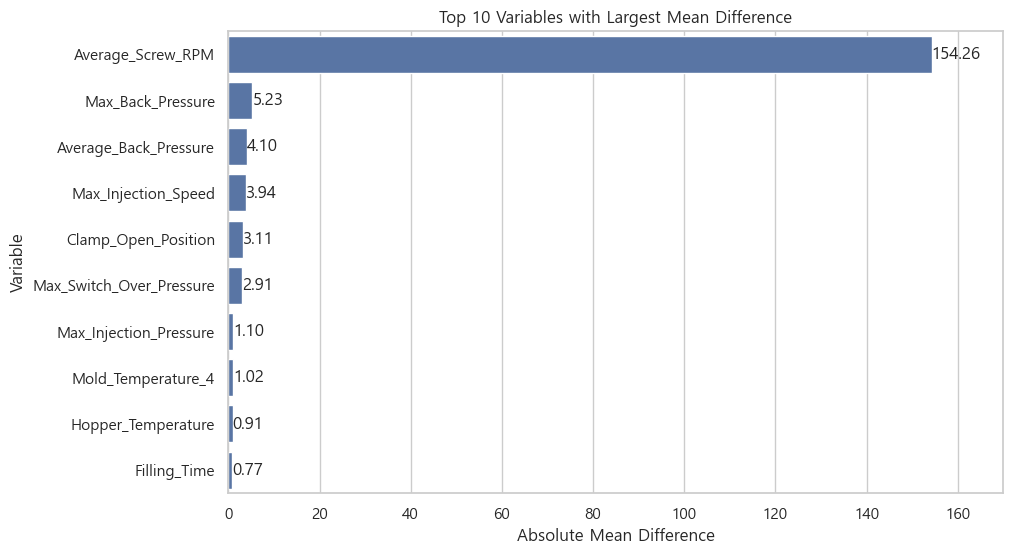

In [20]:
# ---------------------------------------------------------
# 10. 평균 차이가 큰 변수 상위 10개 시각화
# ---------------------------------------------------------
top_diff_cols = group_mean.sort_values("abs_diff", ascending=False).head(10).index.tolist()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=group_mean.loc[top_diff_cols, "abs_diff"],
    y=top_diff_cols
)
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}")
plt.xlim( 0, 170 )
plt.title("Top 10 Variables with Largest Mean Difference")
plt.xlabel("Absolute Mean Difference")
plt.ylabel("Variable")
plt.show()

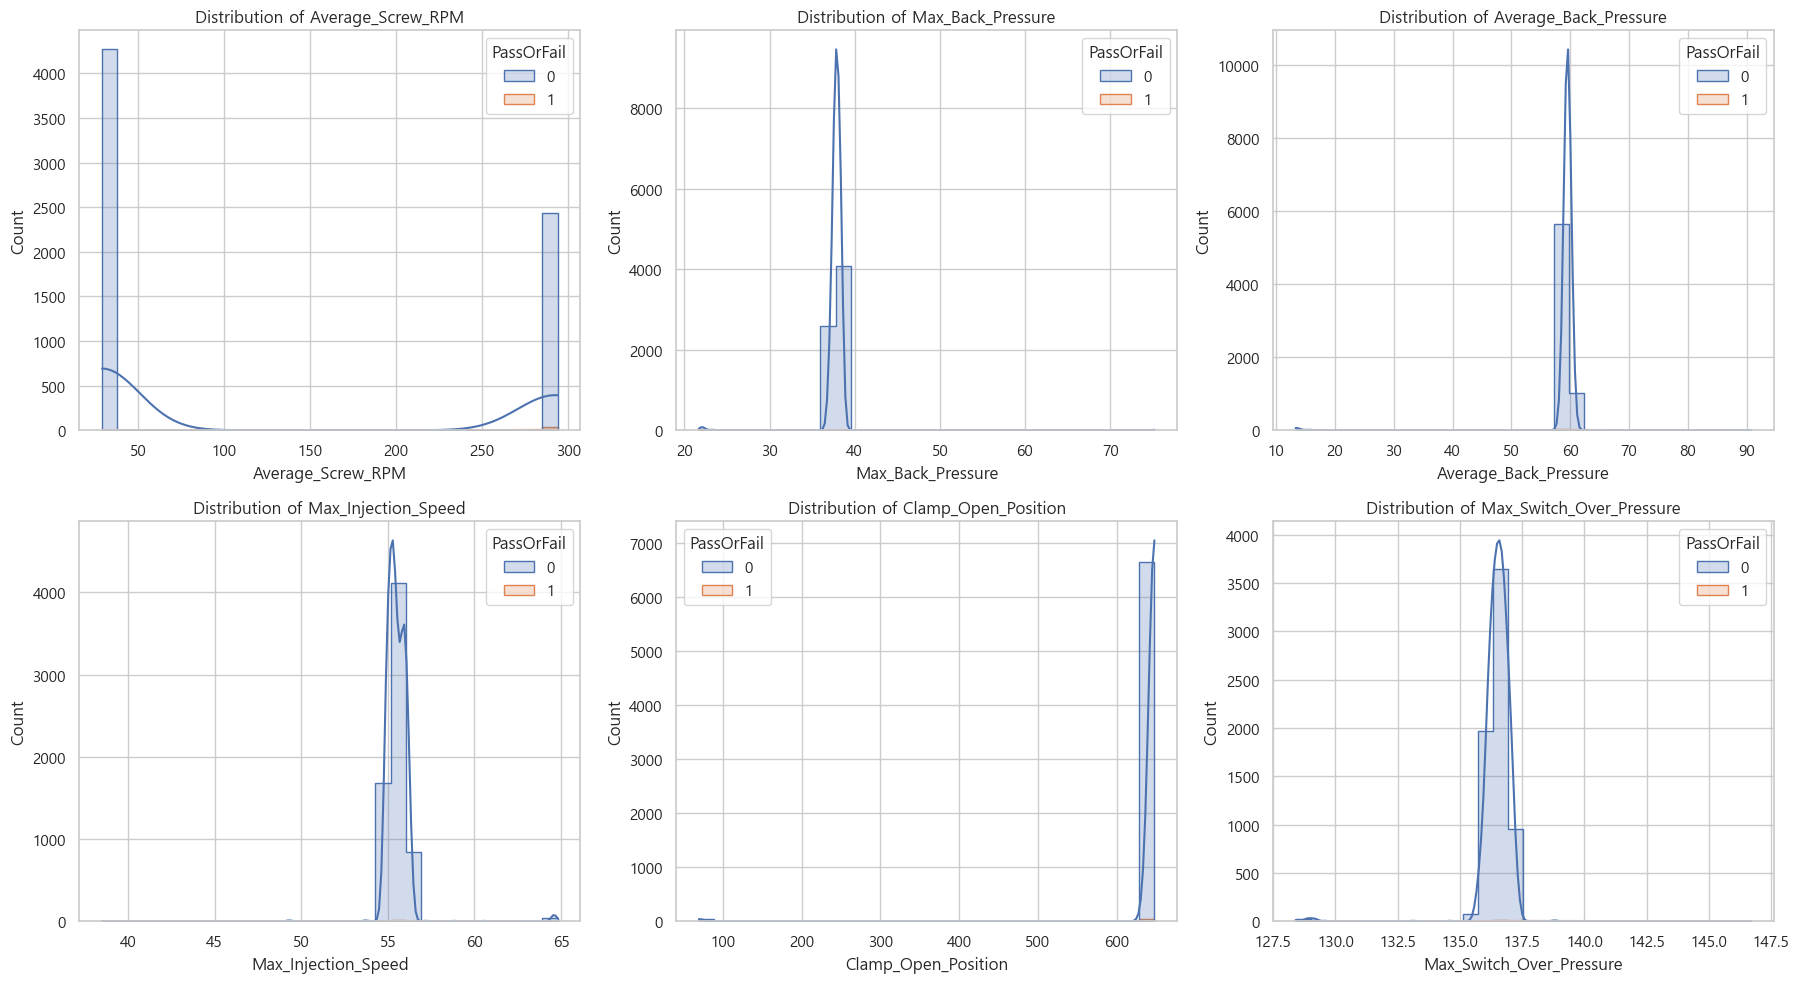

In [21]:
# ---------------------------------------------------------
# 11. 히스토그램 - 주요 변수 분포 확인
# ---------------------------------------------------------
# 평균 차이가 큰 상위 6개 변수만 우선 보기
hist_cols = top_diff_cols[:6]
plt.figure(figsize=(18, 10))
for i, col in enumerate(hist_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue="PassOrFail", bins=30, kde=True, element="step")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

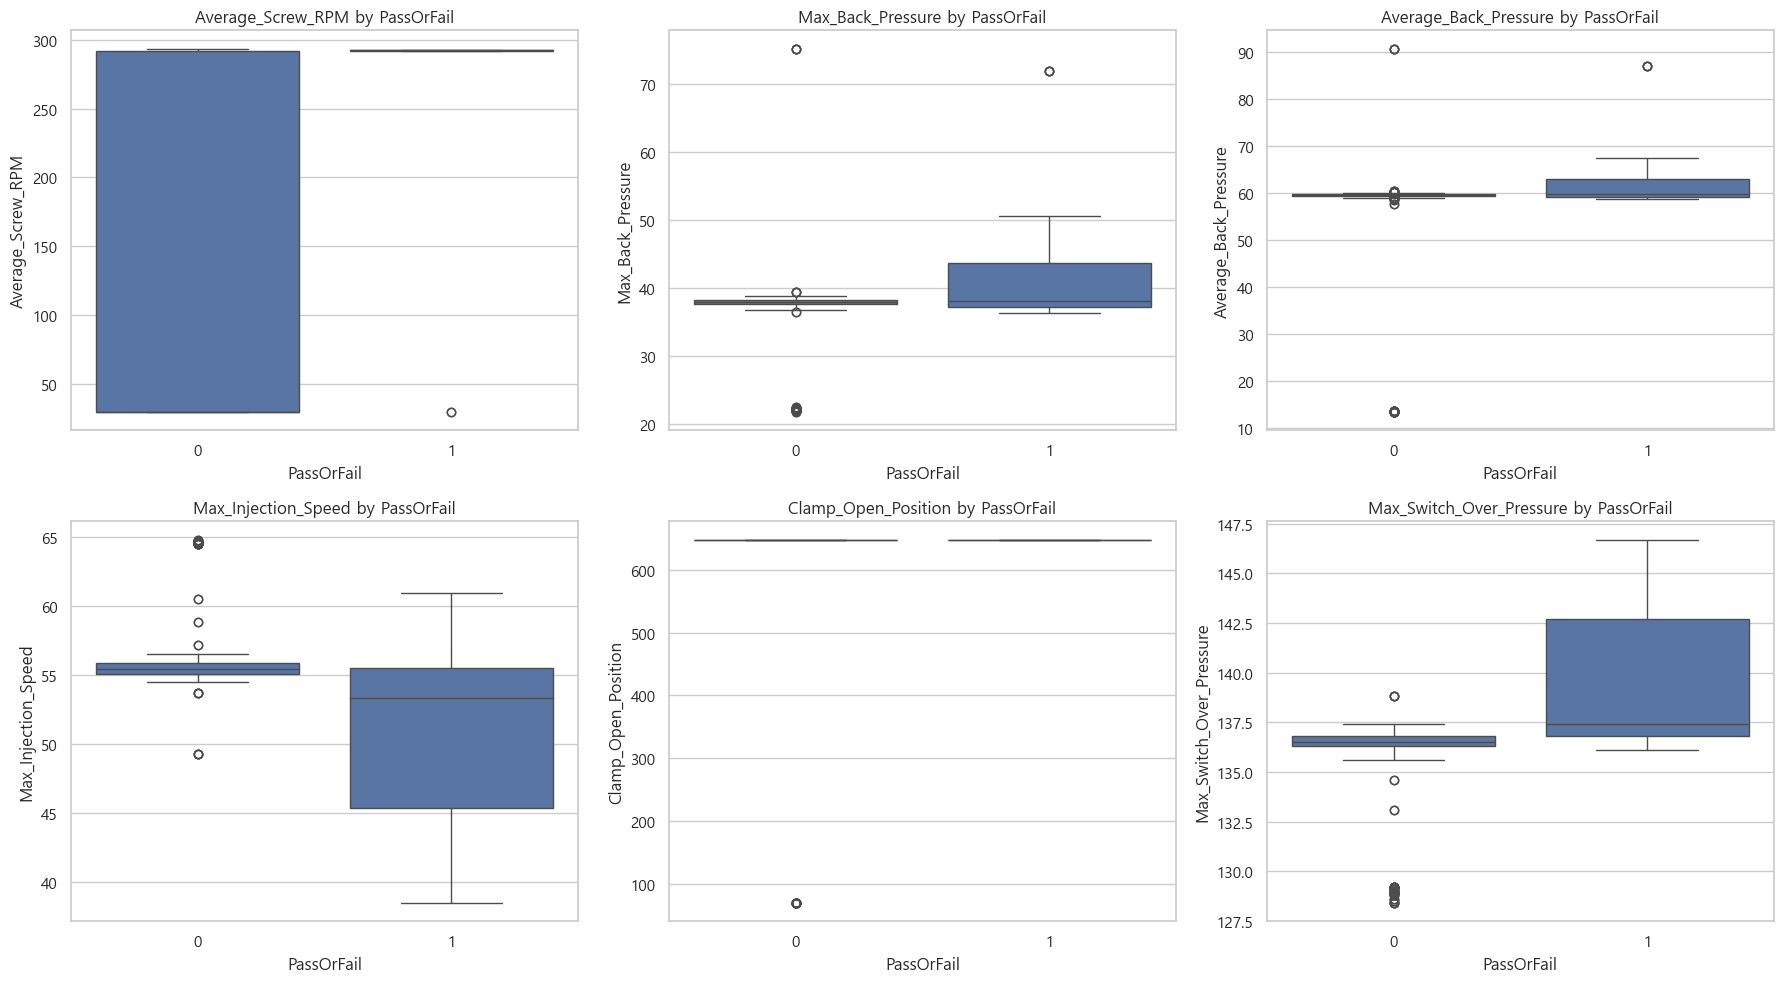

In [22]:
# ---------------------------------------------------------
# 12. boxplot - 주요 변수의 정상/불량 비교
# ---------------------------------------------------------
box_cols = top_diff_cols[:6]
plt.figure(figsize=(18, 10))
for i, col in enumerate(box_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x="PassOrFail", y=col)
    plt.title(f"{col} by PassOrFail")
plt.tight_layout()
plt.show()

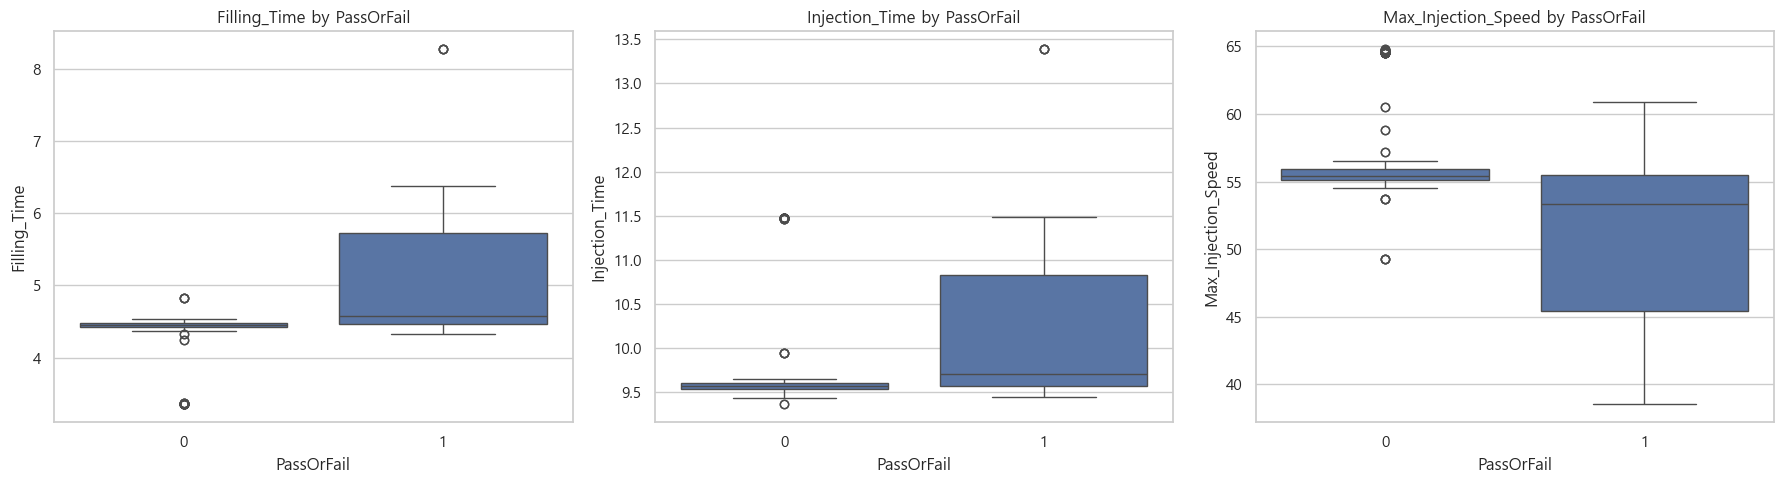

In [23]:
# ---------------------------------------------------------
# 13. 대표 변수 3개를 한 화면에 비교
# ---------------------------------------------------------
# 해석이 쉬운 대표 변수 3개 선택
compare_cols = ["Filling_Time", "Injection_Time", "Max_Injection_Speed"]
plt.figure(figsize=(18, 5))
plt.subplot(131)
sns.boxplot(data=df, x="PassOrFail", y=compare_cols[0])
plt.title(f"{compare_cols[0]} by PassOrFail")
plt.subplot(132)
sns.boxplot(data=df, x="PassOrFail", y=compare_cols[1])
plt.title(f"{compare_cols[1]} by PassOrFail")
plt.subplot(133)
sns.boxplot(data=df, x="PassOrFail", y=compare_cols[2])
plt.title(f"{compare_cols[2]} by PassOrFail")
plt.tight_layout()
plt.show()

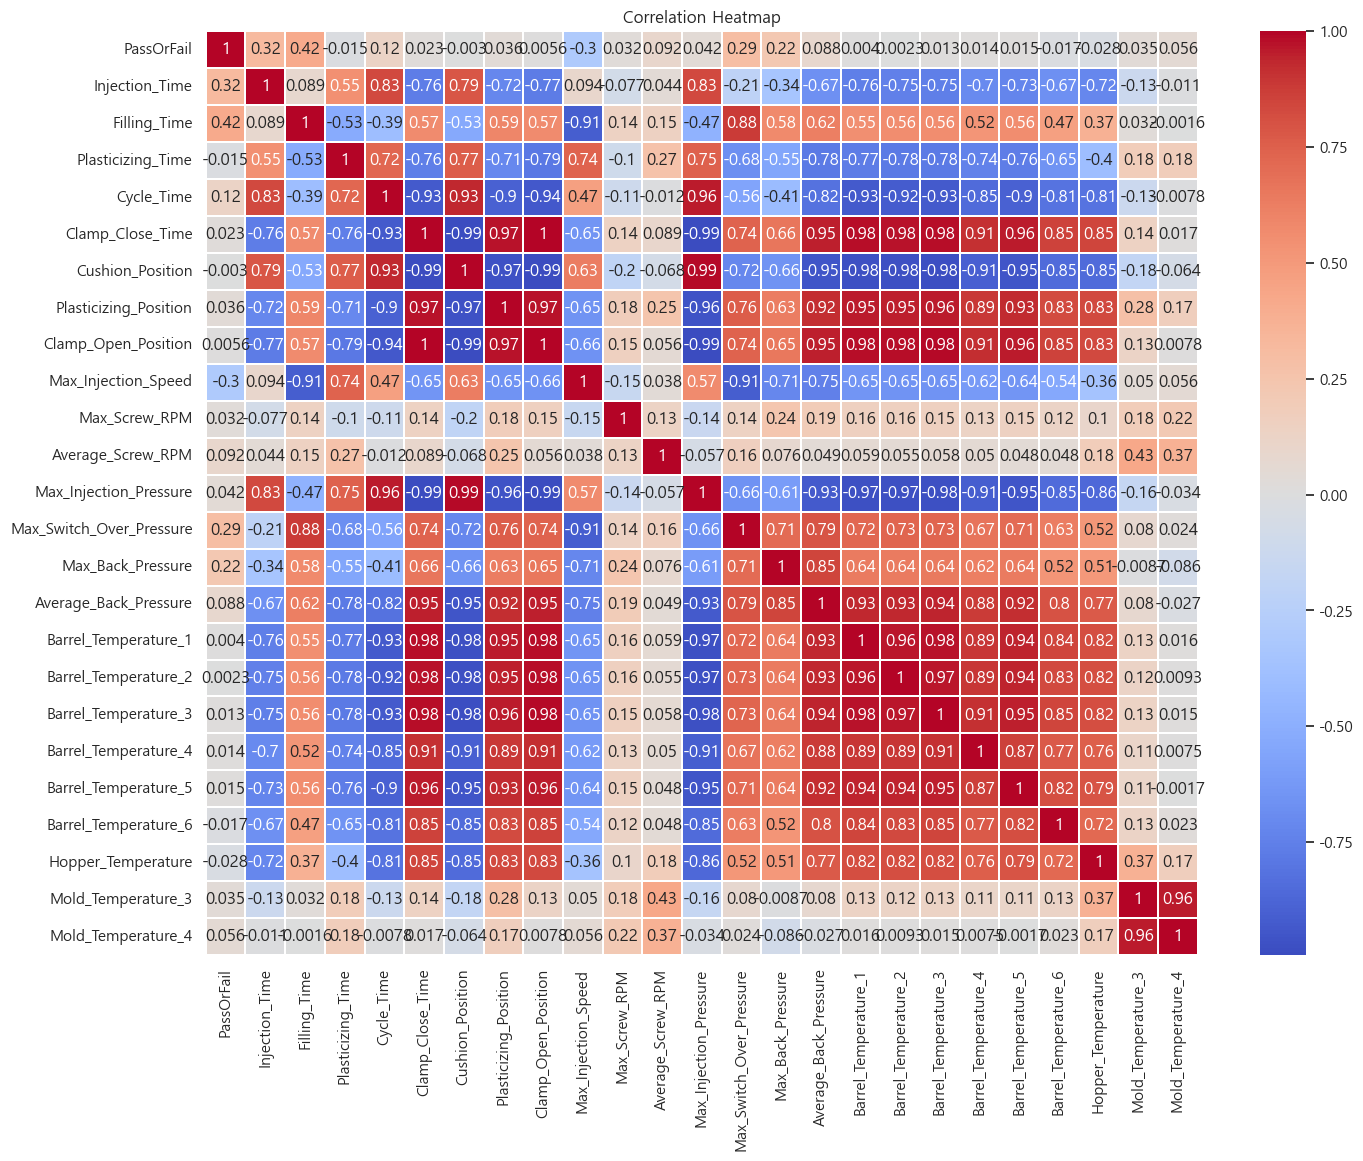

In [24]:
# ---------------------------------------------------------
# 14. 상관분석
# ---------------------------------------------------------
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# ---------------------------------------------------------
# 15. 상관이 큰 변수쌍 상위 15개 보기
# ---------------------------------------------------------
corr_abs = corr.abs()

corr_pairs = corr_abs.stack().reset_index()
corr_pairs.columns = ["var1", "var2", "corr_value"]

# 자기 자신 제거
corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]

# (A,B)와 (B,A)를 같은 쌍으로 처리
corr_pairs["pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["var1"], row["var2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates(subset="pair")
corr_pairs = corr_pairs.sort_values("corr_value", ascending=False)

print("=== 상관이 큰 변수쌍 상위 15개 ===")
display(corr_pairs[["var1", "var2", "corr_value"]].head(15))

=== 상관이 큰 변수쌍 상위 15개 ===


,var1,var2,corr_value
133,Clamp_Close_Time,Clamp_Open_Position,0.996392
158,Cushion_Position,Clamp_Open_Position,0.993846
162,Cushion_Position,Max_Injection_Pressure,0.991699
212,Clamp_Open_Position,Max_Injection_Pressure,0.991552
131,Clamp_Close_Time,Cushion_Position,0.991515
137,Clamp_Close_Time,Max_Injection_Pressure,0.990485
218,Clamp_Open_Position,Barrel_Temperature_3,0.984690
216,Clamp_Open_Position,Barrel_Temperature_1,0.981678
143,Clamp_Close_Time,Barrel_Temperature_3,0.981226
217,Clamp_Open_Position,Barrel_Temperature_2,0.981018


In [26]:
print("PassOrFail와의 상관계수")
target_col = 'PassOrFail'
target_corr = corr[target_col].drop(target_col).sort_values(
    key=lambda x: abs(x),
    ascending=False
)
display(target_corr.to_frame(name="PassOrFail와의 상관계수"))

PassOrFail와의 상관계수


,PassOrFail와의 상관계수
Filling_Time,0.415563
Injection_Time,0.316278
Max_Injection_Speed,-0.297615
Max_Switch_Over_Pressure,0.292394
Max_Back_Pressure,0.224405
Cycle_Time,0.121410
Average_Screw_RPM,0.092282
Average_Back_Pressure,0.088099
Mold_Temperature_4,0.056429
Max_Injection_Pressure,0.042047


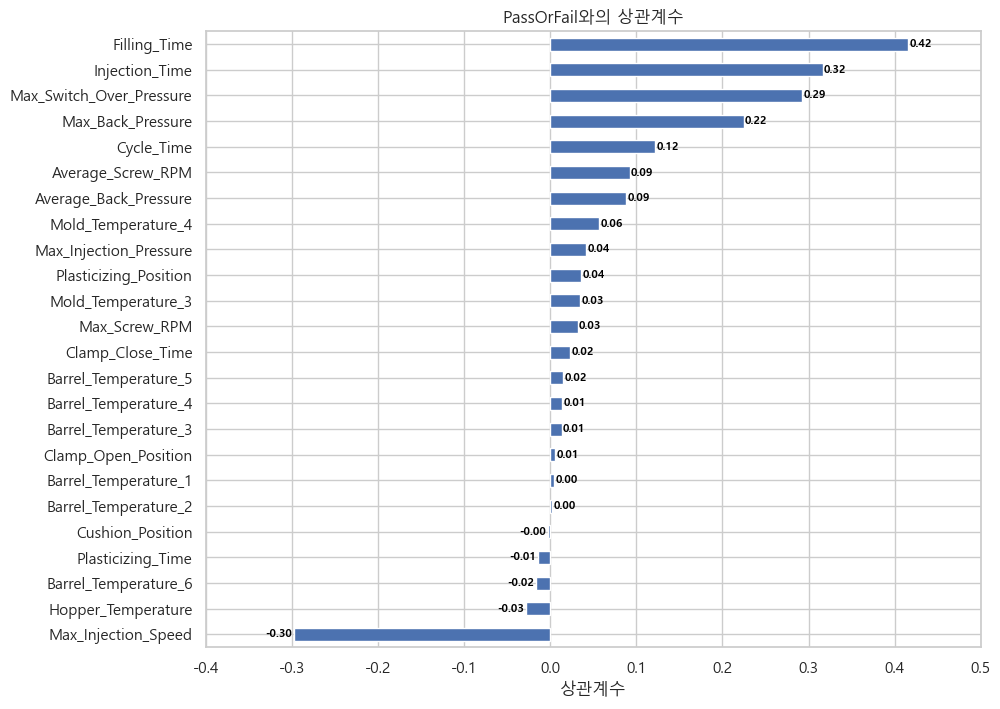

In [27]:
plt.figure(figsize=(10, 8))
ax = target_corr.sort_values().plot(kind="barh")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2f}", label_type='edge', padding=1, fontsize=8, color="black", fontweight="bold")
plt.xlim( -0.4, 0.5 )
plt.title("PassOrFail와의 상관계수")
plt.xlabel("상관계수")
plt.show()

In [28]:
# ---------------------------------------------------------
# 16. PassOrFail 그룹별 상세 통계 비교
# ---------------------------------------------------------
print("=== PassOrFail 그룹별 기술통계량 ===")
group_desc = df.groupby("PassOrFail")[feature_cols].describe()
display(group_desc)

=== PassOrFail 그룹별 기술통계량 ===


Injection_Time                                                 \
                    count       mean       std   min    25%   50%    75%   
PassOrFail                                                                 
0                  6697.0   9.575707  0.144417  9.36  9.530  9.57   9.60   
1                    39.0  10.328205  1.234173  9.44  9.575  9.70  10.83   

                  Filling_Time                                              \
              max        count      mean       std   min   25%   50%   75%   
PassOrFail                                                                   
0           11.48       6697.0  4.443976  0.088029  3.35  4.42  4.45  4.48   
1           13.39         39.0  5.212308  1.232971  4.33  4.46  4.58  5.72   

                 Plasticizing_Time                                             \
             max             count       mean       std        min        25%   
PassOrFail                                                                      
0           4.82            6697.0  16.820754  0.289453  16.520000  16.629999   
1           8.27              39.0  16.765385  0.175677  16.469999  16.615000   

                                    Cycle_Time                       \
              50%    75%        max      count       mean       std   
PassOrFail                                                            
0           16.82  16.91  21.100000     6697.0  59.545866  0.359481   
1           16.82  16.92  16.959999       39.0  60.141539  1.195354   

                                                               \
                  min    25%        50%        75%        max   
PassOrFail                                                      
0           58.840000  59.48  59.520000  59.540001  64.349998   
1           58.959999  59.52  59.560001  60.459999  62.360001   

           Clamp_Close_Time                                               \
                      count      mean       std   min   25%   50%    75%   
PassOrFail                                                                 
0                    6697.0  7.113505  0.076023  6.07  7.12  7.12  7.120   
1                      39.0  7.136667  0.023208  7.11  7.12  7.13  7.135   

                 Cushion_Position                                    \
             max            count        mean       std         min   
PassOrFail                                                            
0           7.14           6697.0  653.440885  0.115223  653.409973   
1           7.18             39.0  653.436406  0.068347  653.390015   

                                                            \
                   25%         50%         75%         max   
PassOrFail                                                   
0           653.429993  653.429993  653.440002  655.000000   
1           653.404999  653.409973  653.429993  653.630005   

           Plasticizing_Position             ... Barrel_Temperature_3  \
                           count       mean  ...                  75%   
PassOrFail                                   ...                        
0                         6697.0  68.380147  ...           275.100006   
1                           39.0  68.689998  ...           275.449997   

                       Barrel_Temperature_4                                    \
                   max                count        mean       std         min   
PassOrFail                                                                      
0           276.000000               6697.0  270.283709  2.022469  244.399994   
1           275.700012                 39.0  270.648717  0.959134  268.899994   

                                                            \
                   25%         50%         75%         max   
PassOrFail                                                   
0           269.700012  270.399994  271.100006  272.399994   
1           270.000000  270.899994  271.449997  272.100006   

           Barrel_Te

In [29]:
# ---------------------------------------------------------
# 17. 간단한 이상치 확인(IQR 기준) - 변수별 이상치 개수
# ---------------------------------------------------------
outlier_summary = []

for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "variable": col,
        "outlier_count": outlier_count,
        "outlier_ratio_percent": round(outlier_count / len(df) * 100, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)

print("=== 변수별 이상치 개수(IQR 기준) ===")
display(outlier_df.head(15))

=== 변수별 이상치 개수(IQR 기준) ===


,variable,outlier_count,outlier_ratio_percent
4,Clamp_Close_Time,2513,37.307
5,Cushion_Position,959,14.237
6,Plasticizing_Position,411,6.102
23,Mold_Temperature_4,375,5.567
19,Barrel_Temperature_5,272,4.038
3,Cycle_Time,110,1.633
14,Average_Back_Pressure,100,1.485
20,Barrel_Temperature_6,88,1.306
15,Barrel_Temperature_1,88,1.306
16,Barrel_Temperature_2,84,1.247


In [30]:
# ---------------------------------------------------------
# 18. 정상/불량 평균 차이 해석용 표 정리
# ---------------------------------------------------------
eda_summary = group_mean.sort_values("abs_diff", ascending=False).copy()
eda_summary["mean_pass_0"] = eda_summary["mean_pass_0"].round(3)
eda_summary["mean_fail_1"] = eda_summary["mean_fail_1"].round(3)
eda_summary["diff_fail_minus_pass"] = eda_summary["diff_fail_minus_pass"].round(3)
eda_summary["abs_diff"] = eda_summary["abs_diff"].round(3)

print("=== EDA 핵심 요약표 ===")
display(eda_summary.head(15))

=== EDA 핵심 요약표 ===


,mean_pass_0,mean_fail_1,diff_fail_minus_pass,abs_diff
Average_Screw_RPM,124.691,278.954,154.263,154.263
Max_Back_Pressure,37.812,43.041,5.229,5.229
Average_Back_Pressure,59.323,63.423,4.100,4.100
Max_Injection_Speed,55.546,51.603,-3.943,3.943
Clamp_Open_Position,644.881,647.990,3.109,3.109
Max_Switch_Over_Pressure,136.502,139.410,2.908,2.908
Max_Injection_Pressure,142.084,143.185,1.100,1.100
Mold_Temperature_4,23.468,24.487,1.019,1.019
Hopper_Temperature,66.668,65.756,-0.912,0.912
Filling_Time,4.444,5.212,0.768,0.768


In [31]:
# ---------------------------------------------------------
# 19. 해석용 문장 자동 출력
# ---------------------------------------------------------
print("=== 평균 차이가 큰 상위 5개 변수 해석 ===")
for col in eda_summary.head(5).index:
    pass_mean = eda_summary.loc[col, "mean_pass_0"]
    fail_mean = eda_summary.loc[col, "mean_fail_1"]

    if fail_mean > pass_mean:
        print(f"- {col}: 불량(1) 평균이 정상(0)보다 높습니다. ({fail_mean} > {pass_mean})")
    else:
        print(f"- {col}: 불량(1) 평균이 정상(0)보다 낮습니다. ({fail_mean} < {pass_mean})")

=== 평균 차이가 큰 상위 5개 변수 해석 ===
- Average_Screw_RPM: 불량(1) 평균이 정상(0)보다 높습니다. (278.954 > 124.691)
- Max_Back_Pressure: 불량(1) 평균이 정상(0)보다 높습니다. (43.041 > 37.812)
- Average_Back_Pressure: 불량(1) 평균이 정상(0)보다 높습니다. (63.423 > 59.323)
- Max_Injection_Speed: 불량(1) 평균이 정상(0)보다 낮습니다. (51.603 < 55.546)
- Clamp_Open_Position: 불량(1) 평균이 정상(0)보다 높습니다. (647.99 > 644.881)


In [32]:
# ---------------------------------------------------------
# 20. 최종 정리
# ---------------------------------------------------------
print("\n=== EDA 최종 정리 ===")
print("1. 데이터 크기와 컬럼 구조를 확인했다.")
print("2. 결측치와 중복 여부를 확인했다.")
print("3. PassOrFail 분포를 확인했다.")
print("4. 기술통계와 그룹별 평균 차이를 확인했다.")
print("5. 히스토그램과 boxplot으로 주요 변수 분포를 비교했다.")
print("6. 상관분석으로 변수 간 관계를 확인했다.")
print("7. 이상치 개수를 확인했다.")
print("8. 불량/정상 차이가 큰 핵심 변수 후보를 찾았다.")


=== EDA 최종 정리 ===
1. 데이터 크기와 컬럼 구조를 확인했다.
2. 결측치와 중복 여부를 확인했다.
3. PassOrFail 분포를 확인했다.
4. 기술통계와 그룹별 평균 차이를 확인했다.
5. 히스토그램과 boxplot으로 주요 변수 분포를 비교했다.
6. 상관분석으로 변수 간 관계를 확인했다.
7. 이상치 개수를 확인했다.
8. 불량/정상 차이가 큰 핵심 변수 후보를 찾았다.


In [33]:
# end